# Sales Prediction using Machine Learning in Python

# Import Libraries

In [1]:
# Core Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Model Saving
import joblib
import os

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")


# Load Dataset

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/advertising-csv/advertising (1).csv


In [3]:
df = pd.read_csv("/kaggle/input/advertising-csv/advertising (1).csv")
df.head()


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


# Exploratory Data Analysis (EDA)

# Correlation Matrix

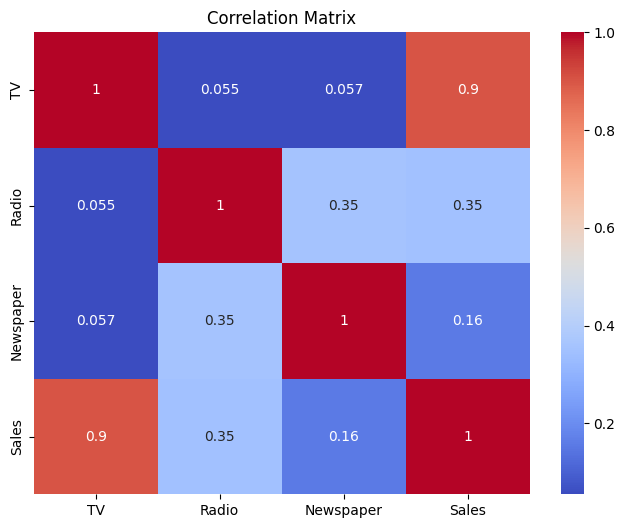

In [5]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


# Pairplot

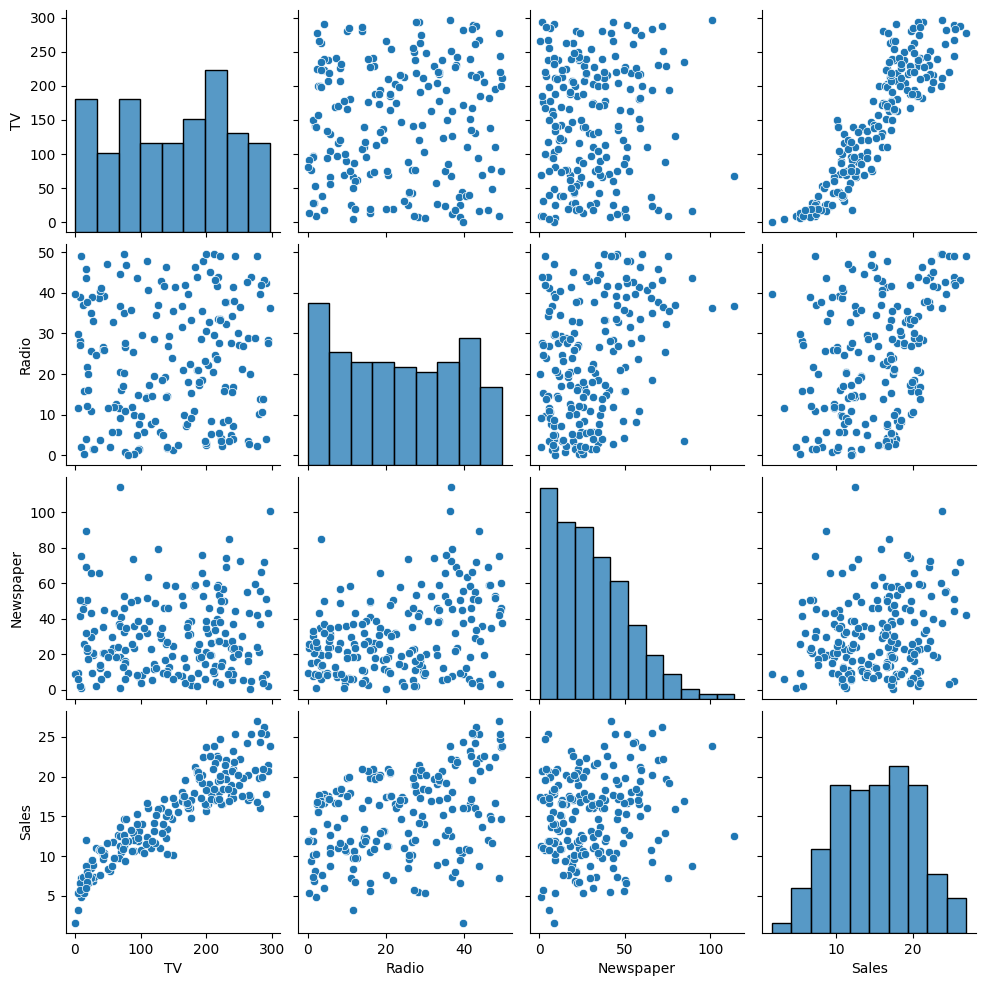

In [6]:
sns.pairplot(df)
plt.show()


# Distribution Plots

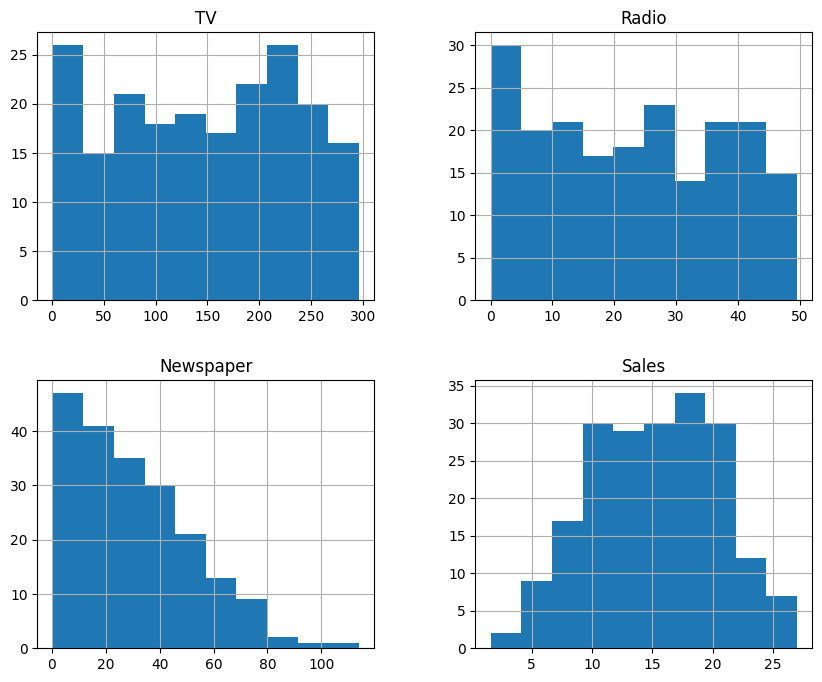

In [7]:
df.hist(figsize=(10,8))
plt.show()


# Feature vs Target Relationship

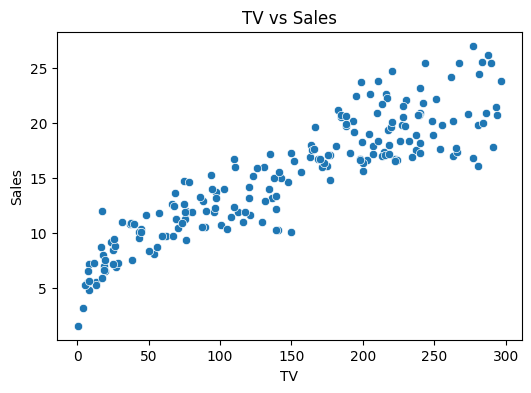

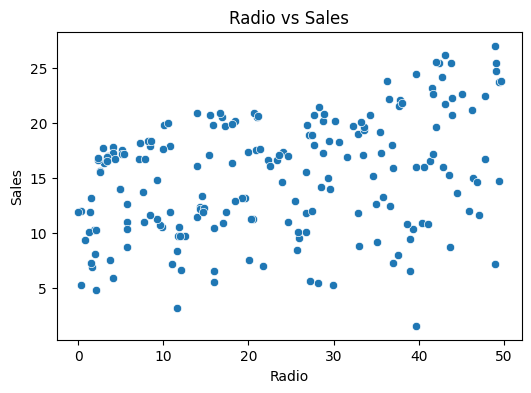

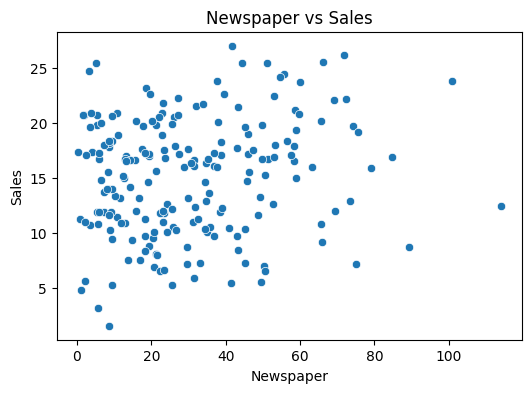

In [8]:
features = ['TV','Radio','Newspaper']

for feature in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[feature], y=df['Sales'])
    plt.title(f"{feature} vs Sales")
    plt.show()


# Target Variable Deep Analysis

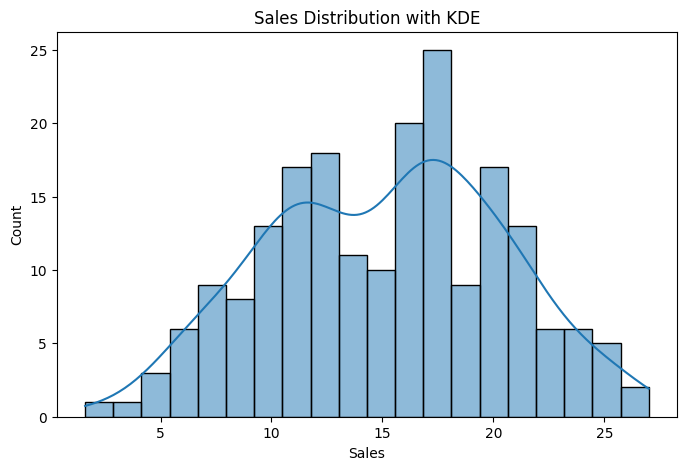

Skewness: -0.07373923537186912
Kurtosis: -0.640074901678739


In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], kde=True, bins=20)
plt.title("Sales Distribution with KDE")
plt.show()

print("Skewness:", df['Sales'].skew())
print("Kurtosis:", df['Sales'].kurt())


# Outlier Detection (Boxplots)

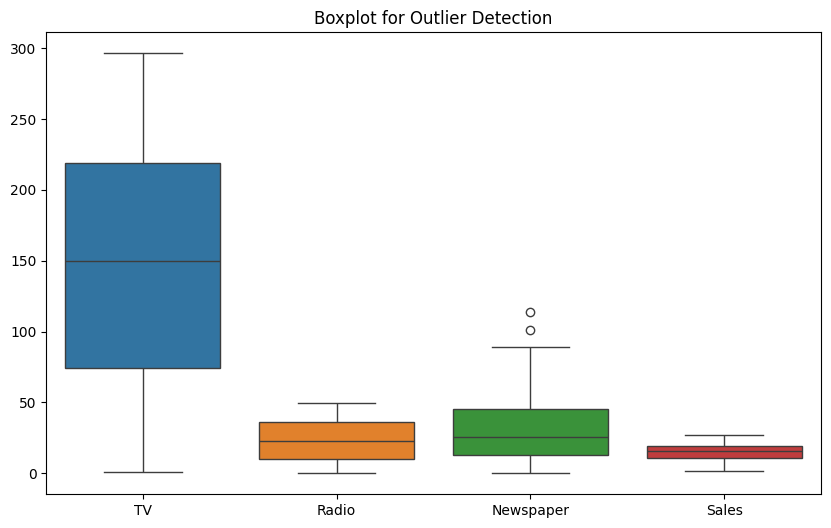

In [10]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title("Boxplot for Outlier Detection")
plt.show()


# Using IQR Method

In [11]:
def detect_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return outliers

for col in df.columns:
    print(f"{col} Outliers:", len(detect_outliers(col)))


TV Outliers: 0
Radio Outliers: 0
Newspaper Outliers: 2
Sales Outliers: 0


# Multicollinearity Check

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df.drop("Sales", axis=1)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(len(X_vif.columns))
]

vif_data


,Feature,VIF
0,TV,2.486772
1,Radio,3.285462
2,Newspaper,3.055245


# Feature Interaction Analysis

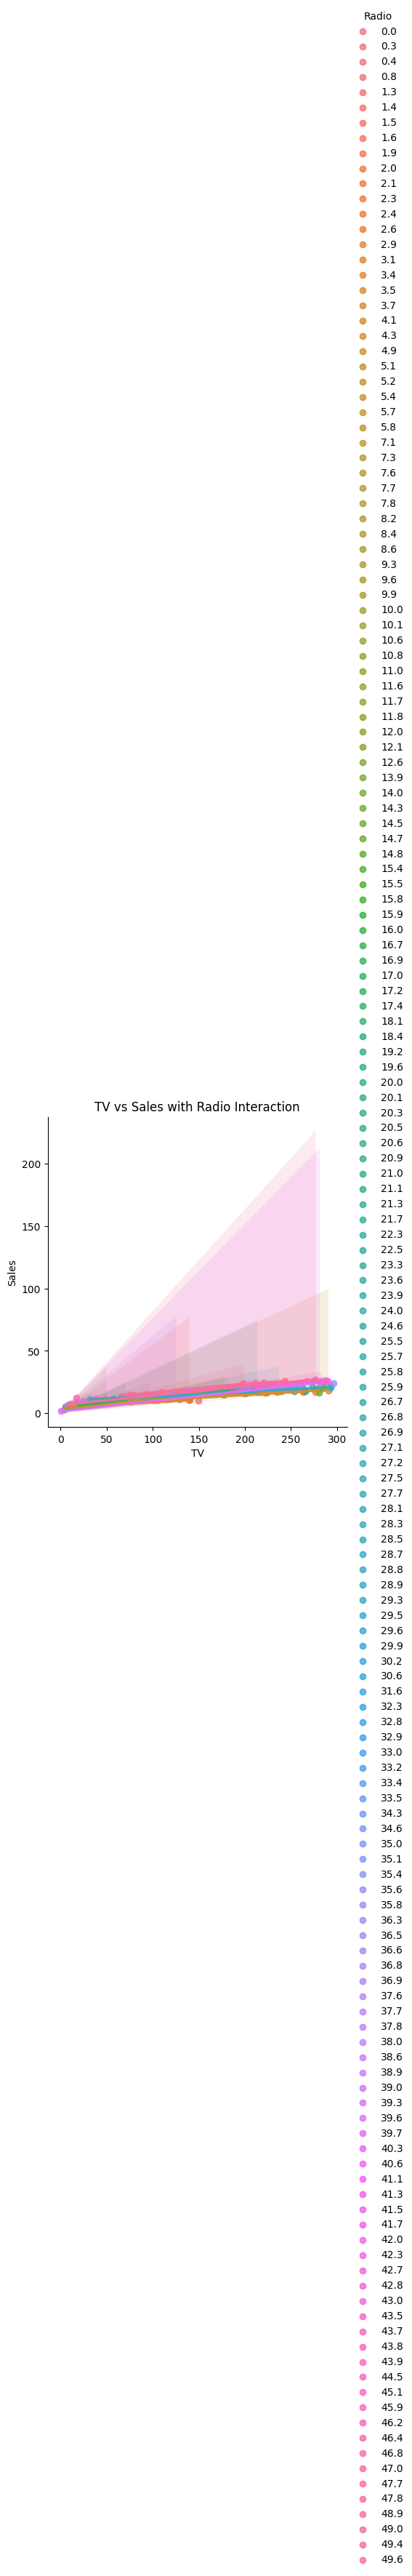

In [13]:
sns.lmplot(x="TV", y="Sales", hue="Radio", data=df)
plt.title("TV vs Sales with Radio Interaction")
plt.show()


# Advertising Budget Contribution %

In [14]:
df['Total_Ad_Spend'] = df['TV'] + df['Radio'] + df['Newspaper']

df['TV_ratio'] = df['TV'] / df['Total_Ad_Spend']
df['Radio_ratio'] = df['Radio'] / df['Total_Ad_Spend']
df['Newspaper_ratio'] = df['Newspaper'] / df['Total_Ad_Spend']

df[['TV_ratio','Radio_ratio','Newspaper_ratio']].head()


,TV_ratio,Radio_ratio,Newspaper_ratio
0,0.682587,0.112133,0.205280
1,0.345229,0.304888,0.349884
2,0.129909,0.346677,0.523414
3,0.602865,0.164345,0.232789
4,0.723200,0.043200,0.233600


# Sales vs Total Advertising Spend

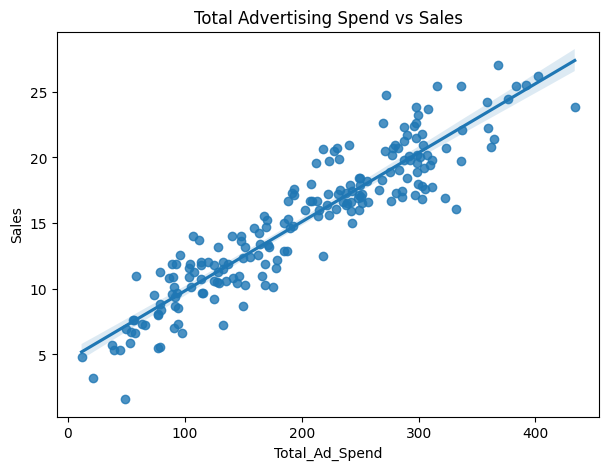

In [15]:
plt.figure(figsize=(7,5))
sns.regplot(x=df['Total_Ad_Spend'], y=df['Sales'])
plt.title("Total Advertising Spend vs Sales")
plt.show()


# Residual Analysis (After Linear Regression)

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])




In [17]:
from sklearn.model_selection import train_test_split

X = df.drop("Sales", axis=1)
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


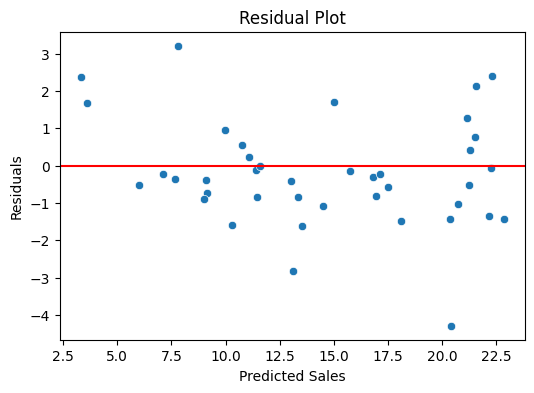

In [18]:
linear_pipeline.fit(X_train, y_train)
y_pred = linear_pipeline.predict(X_test)

residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
plt.title("Residual Plot")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.show()


# Normality Test (Shapiro-Wilk)

In [19]:
from scipy.stats import shapiro

stat, p = shapiro(df['Sales'])
print("p-value:", p)

if p > 0.05:
    print("Sales looks normally distributed")
else:
    print("Sales is not normally distributed")


p-value: 0.07644931187386997
Sales looks normally distributed


# Correlation with P-values (Statistical Significance)

In [20]:
import scipy.stats as stats

for col in ['TV','Radio','Newspaper']:
    corr, p_value = stats.pearsonr(df[col], df['Sales'])
    print(f"{col} Correlation: {corr:.3f}, P-value: {p_value:.5f}")


TV Correlation: 0.901, P-value: 0.00000
Radio Correlation: 0.350, P-value: 0.00000
Newspaper Correlation: 0.158, P-value: 0.02549


# Polynomial Relationship Check

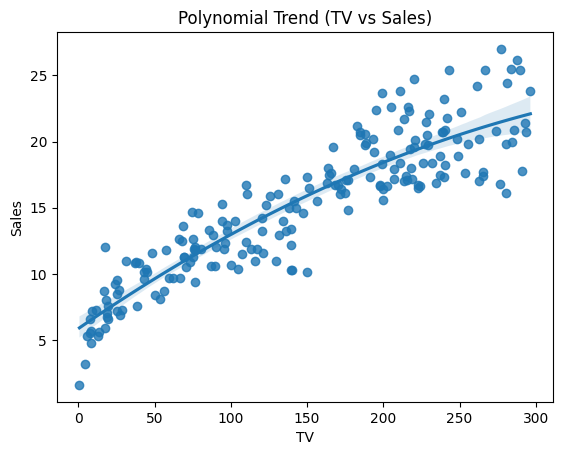

In [21]:
sns.regplot(x="TV", y="Sales", data=df, order=2)
plt.title("Polynomial Trend (TV vs Sales)")
plt.show()



# Advanced Heatmap with Mask

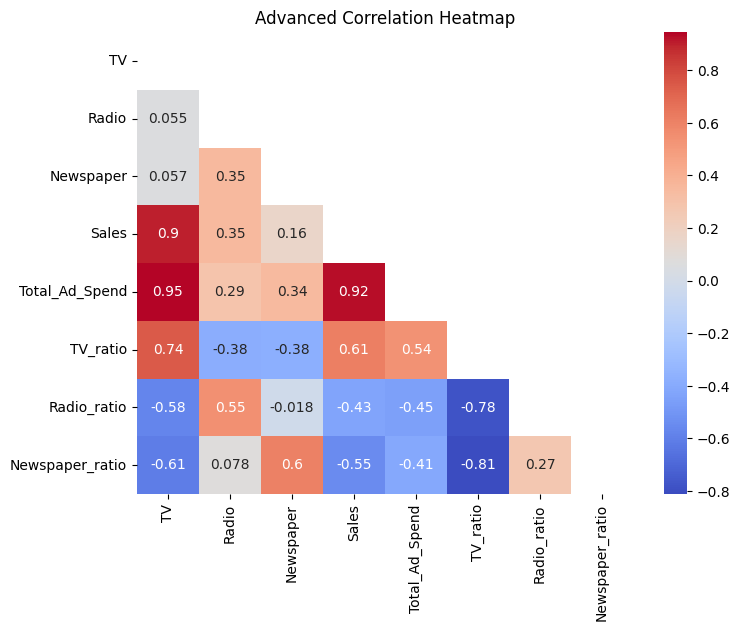

In [22]:
plt.figure(figsize=(8,6))
corr_matrix = df.corr()

mask = np.triu(corr_matrix)

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", mask=mask)
plt.title("Advanced Correlation Heatmap")
plt.show()


# Clustering Visualization

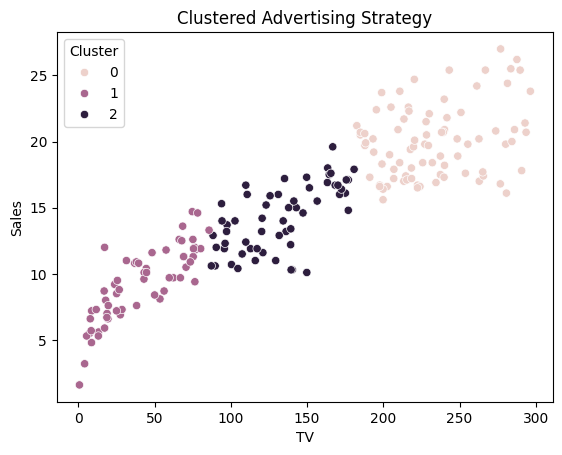

In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(df[['TV','Radio','Newspaper']])

sns.scatterplot(x="TV", y="Sales", hue="Cluster", data=df)
plt.title("Clustered Advertising Strategy")
plt.show()


# Feature Engineering

In [24]:
X = df.drop("Sales", axis=1)
y = df["Sales"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Model Building (Multiple Algorithms)

# Linear Regression Pipeline

In [25]:
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)
y_pred_lr = linear_pipeline.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))


Linear Regression R2: 0.9352032456900816


# Random Forest (Advanced Model)

In [26]:
rf_pipeline = Pipeline([
    ("model", RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))


Random Forest R2: 0.8955235501325192


# Gradient Boosting

In [27]:
gb_pipeline = Pipeline([
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_pipeline.fit(X_train, y_train)
y_pred_gb = gb_pipeline.predict(X_test)

print("Gradient Boosting R2:", r2_score(y_test, y_pred_gb))


Gradient Boosting R2: 0.9268015927664186


# Model Evaluation Function

In [28]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print("R2 Score:", r2)
    print("MAE:", mae)
    print("RMSE:", rmse)
    
    return r2


In [29]:
print("Linear Regression")
evaluate_model(linear_pipeline, X_test, y_test)

print("\nRandom Forest")
evaluate_model(rf_pipeline, X_test, y_test)

print("\nGradient Boosting")
evaluate_model(gb_pipeline, X_test, y_test)


Linear Regression
R2 Score: 0.9352032456900816
MAE: 1.0987107646717906
RMSE: 1.4150233159231758

Random Forest
R2 Score: 0.8955235501325192
MAE: 1.2395750000000032
RMSE: 1.7967852473236778

Gradient Boosting
R2 Score: 0.9268015927664186
MAE: 1.0972107663903496
RMSE: 1.5039651930033564


0.9268015927664186

# Hyperparameter Tuning

In [30]:
param_grid = {
    "model__n_estimators": [100,200,300],
    "model__max_depth": [None,5,10]
}

grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)


Best Parameters: {'model__max_depth': None, 'model__n_estimators': 300}
Best Score: 0.9244320530743986


# Feature Importance

# Save Best Model 

In [31]:

best_model = grid.best_estimator_


In [32]:
best_model = rf_pipeline   # or linear_pipeline or gb_pipeline


In [33]:
import os
import joblib

os.makedirs("models", exist_ok=True)
joblib.dump(best_model, "models/best_model.pkl")
print("Model Saved Successfully!")


Model Saved Successfully!


In [34]:
import os
import joblib

MODEL_DIR = "models"
MODEL_PATH = os.path.join(MODEL_DIR, "best_model.pkl")

os.makedirs(MODEL_DIR, exist_ok=True)

try:
    joblib.dump(best_model, MODEL_PATH)
    print(f"Model saved successfully at {MODEL_PATH}")
except Exception as e:
    print("Error saving model:", e)


Model saved successfully at models/best_model.pkl


# Prediction Function (Deployment Ready)

In [35]:

def predict_sales(tv, radio, newspaper):
    import joblib
    import pandas as pd
    
    model = joblib.load("models/best_model.pkl")
    
    # Create base dataframe
    input_data = pd.DataFrame({
        "TV": [tv],
        "Radio": [radio],
        "Newspaper": [newspaper]
    })
    
    # ---- Feature Engineering (MUST match training) ----
    input_data["Total_Ad_Spend"] = (
        input_data["TV"] +
        input_data["Radio"] +
        input_data["Newspaper"]
    )
    
    input_data["TV_ratio"] = input_data["TV"] / input_data["Total_Ad_Spend"]
    input_data["Radio_ratio"] = input_data["Radio"] / input_data["Total_Ad_Spend"]
    input_data["Newspaper_ratio"] = input_data["Newspaper"] / input_data["Total_Ad_Spend"]
    
    # If clustering was used
    from sklearn.cluster import KMeans
    kmeans = KMeans(n_clusters=3, random_state=42)
    kmeans.fit(df[['TV','Radio','Newspaper']])   # fit on training structure
    input_data["Cluster"] = kmeans.predict(input_data[['TV','Radio','Newspaper']])
    
    # -----------------------------------------------
    
    prediction = model.predict(input_data)[0]
    
    return round(prediction, 2)


In [36]:
from sklearn.preprocessing import FunctionTransformer

def feature_engineering(X):
    X = X.copy()
    X["Total_Ad_Spend"] = X["TV"] + X["Radio"] + X["Newspaper"]
    X["TV_ratio"] = X["TV"] / X["Total_Ad_Spend"]
    X["Radio_ratio"] = X["Radio"] / X["Total_Ad_Spend"]
    X["Newspaper_ratio"] = X["Newspaper"] / X["Total_Ad_Spend"]
    return X

feature_transformer = FunctionTransformer(feature_engineering)

pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("model", RandomForestRegressor())
])
